In [213]:
import pandas as pd

df = pd.read_csv(r"E:\Study\DEPI DS 20-26\Technical\DA\SuperStoreOrders - SuperStoreOrders.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.columns)
print(df.dtypes)

          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

In [214]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

df['sales'] = pd.to_numeric(df['sales'].str.replace(',', ''))

In [215]:
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year

In [216]:
df.dtypes

order_id                  object
order_date        datetime64[ns]
ship_date         datetime64[ns]
ship_mode                 object
customer_name             object
segment                   object
state                     object
country                   object
market                    object
region                    object
product_id                object
category                  object
sub_category              object
product_name              object
sales                      int64
quantity                   int64
discount                 float64
profit                   float64
shipping_cost            float64
order_priority            object
year                       int32
shipping_days              int64
month                      int32
dtype: object

In [217]:
df['profit_margin'] = df['profit'] / df['sales']
df['unit_price'] = df['sales'] / df['quantity']
df['category'] = df['category'].str.strip()

In [218]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,month,profit_margin,unit_price
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,2,0.0,106.140,35.46,Medium,2011,5,1,0.260147,204.0
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,3,0.1,36.036,9.72,Medium,2011,7,1,0.300300,40.0
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,4,0.0,29.640,8.17,High,2011,4,1,0.449091,16.5
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,3,0.5,-26.055,4.82,High,2011,4,1,-0.579000,15.0
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,5,0.1,37.770,4.70,Medium,2011,7,1,0.331316,22.8


In [219]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
shipping_days     0
month             0
profit_margin     0
unit_price        0
dtype: int64

In [220]:
df.duplicated().sum()

np.int64(0)

In [221]:
df.nunique()

order_id          25035
order_date         1430
ship_date          1464
ship_mode             4
customer_name       795
segment               3
state              1094
country             147
market                7
region               13
product_id        10292
category              3
sub_category         17
product_name       3788
sales              2246
quantity             14
discount             27
profit            24575
shipping_cost     10037
order_priority        4
year                  4
shipping_days         8
month                12
profit_margin     29001
unit_price         5310
dtype: int64

In [222]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'ship_mode',
        'segment',
        'market',
        'region',
        'category',
        'sub_category',
        'order_priority'
    ],
    drop_first=True
)
df_encoded

,order_id,order_date,ship_date,customer_name,state,country,product_id,product_name,sales,quantity,...,sub_category_Labels,sub_category_Machines,sub_category_Paper,sub_category_Phones,sub_category_Storage,sub_category_Supplies,sub_category_Tables,order_priority_High,order_priority_Low,order_priority_Medium
0,AG-2011-2040,2011-01-01,2011-01-06,Toby Braunhardt,Constantine,Algeria,OFF-TEN-10000025,"Tenex Lockers, Blue",408,2,...,False,False,False,False,True,False,False,False,False,True
1,IN-2011-47883,2011-01-01,2011-01-08,Joseph Holt,New South Wales,Australia,OFF-SU-10000618,"Acme Trimmer, High Speed",120,3,...,False,False,False,False,False,True,False,False,False,True
2,HU-2011-1220,2011-01-01,2011-01-05,Annie Thurman,Budapest,Hungary,OFF-TEN-10001585,"Tenex Box, Single Width",66,4,...,False,False,False,False,True,False,False,True,False,False
3,IT-2011-3647632,2011-01-01,2011-01-05,Eugene Moren,Stockholm,Sweden,OFF-PA-10001492,"Enermax Note Cards, Premium",45,3,...,False,False,True,False,False,False,False,True,False,False
4,IN-2011-47883,2011-01-01,2011-01-08,Joseph Holt,New South Wales,Australia,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",114,5,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-01-04,Erica Bern,California,United States,OFF-BI-10002103,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,...,False,False,False,False,False,False,False,False,False,True
51286,MO-2014-2560,2014-12-31,2015-01-05,Liz Preis,Souss-Massa-Draâ,Morocco,OFF-WIL-10001069,"Wilson Jones Hole Reinforcements, Clear",4,1,...,False,False,False,False,False,False,False,False,False,True
51287,MX-2014-110527,2014-12-31,2015-01-02,Charlotte Melton,Managua,Nicaragua,OFF-LA-10004182,"Hon Color Coded Labels, 5000 Label Set",26,3,...,True,False,False,False,False,False,False,False,False,True
51288,MX-2014-114783,2014-12-31,2015-01-06,Tamara Dahlen,Chihuahua,Mexico,OFF-LA-10000413,"Hon Legal Exhibit Labels, Alphabetical",7,1,...,True,False,False,False,False,False,False,False,False,True


In [223]:
df_reduced= df.groupby('category')['sales'].sum().sort_values(ascending=False)
df_reduced.head()

category
Technology         4744691
Furniture          4110884
Office Supplies    3787330
Name: sales, dtype: int64

<Axes: xlabel='profit'>

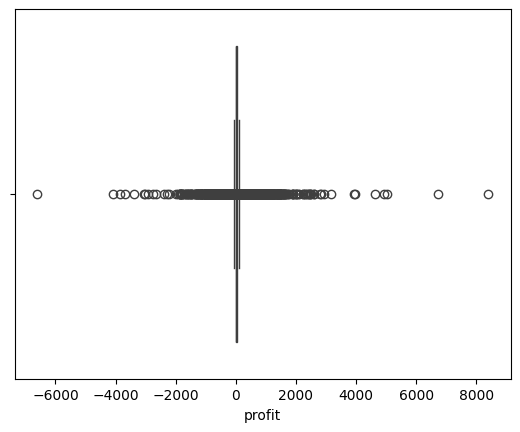

In [224]:
import seaborn as sns
sns.boxplot(x=df['profit'])

In [225]:
Q1 = df['profit'].quantile(0.25)
Q3 = df['profit'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['profit'] < lower) | (df['profit'] > upper)]

print(len(outliers))

df_clean = df[(df['profit'] >= lower) & (df['profit'] <= upper)]
print(df_clean)

9755
              order_id order_date  ship_date       ship_mode  \
1        IN-2011-47883 2011-01-01 2011-01-08  Standard Class   
2         HU-2011-1220 2011-01-01 2011-01-05    Second Class   
3      IT-2011-3647632 2011-01-01 2011-01-05    Second Class   
4        IN-2011-47883 2011-01-01 2011-01-08  Standard Class   
5        IN-2011-47883 2011-01-01 2011-01-08  Standard Class   
...                ...        ...        ...             ...   
51285   CA-2014-115427 2014-12-31 2015-01-04  Standard Class   
51286     MO-2014-2560 2014-12-31 2015-01-05  Standard Class   
51287   MX-2014-110527 2014-12-31 2015-01-02    Second Class   
51288   MX-2014-114783 2014-12-31 2015-01-06  Standard Class   
51289   CA-2014-156720 2014-12-31 2015-01-04  Standard Class   

          customer_name      segment             state        country  market  \
1           Joseph Holt     Consumer   New South Wales      Australia    APAC   
2         Annie Thurman     Consumer          Budapest        Hu